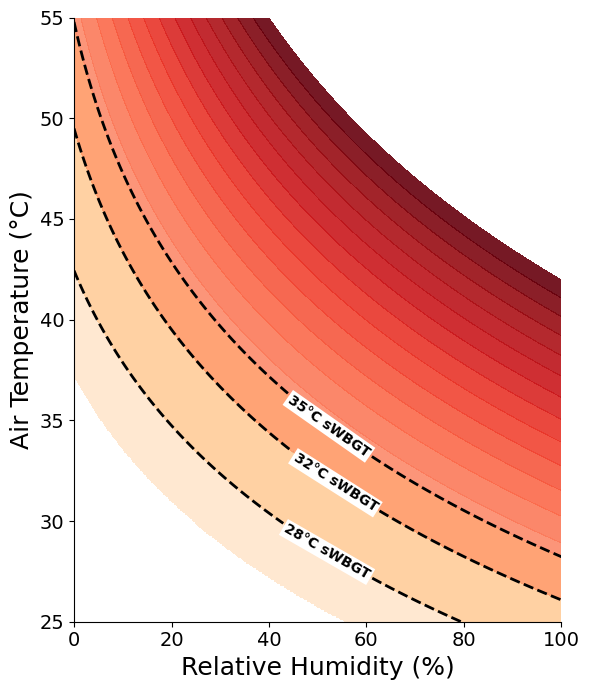

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================================================
# Functions
# =========================================================

def vapor_pressure(Ta, rh):
    return (rh / 100.0) * 6.112 * np.exp((17.67 * Ta) / (243.5 + Ta))

def wbgt(Ta, rh):
    e = vapor_pressure(Ta, rh)
    return 0.567 * Ta + 0.393 * e + 3.94

# =========================================================
# Create grid
# =========================================================
Ta = np.linspace(25, 55, 301)
rh = np.linspace(0, 100, 401)

RH, TA = np.meshgrid(rh, Ta)

WBGT = wbgt(TA, RH)

# Mask values <= 25°C
WBGT_masked = np.ma.masked_where(WBGT <= 25, WBGT)

# =========================================================
# Colour levels
# =========================================================
bounds = [25, 28, 32, 35] + list(np.arange(36, 61, 2))

light_colors = [
    "#ffe6cc",
    "#ffcc99",
    "#ff9966"
]

red_grad = plt.cm.Reds(
    np.linspace(0.4, 1.0, len(bounds) - 4)
)

colors = light_colors + [
    plt.matplotlib.colors.to_hex(c)
    for c in red_grad
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots(figsize=(6, 7))

cf = ax.contourf(
    RH,
    TA,
    WBGT_masked,
    levels=bounds,
    cmap=cmap,
    norm=norm,
    alpha=0.9
)

# =========================================================
# Draw and label contours separately
# =========================================================

# 28°C contour
cs28 = ax.contour(
    RH,
    TA,
    WBGT,
    levels=[28],
    colors="black",
    linestyles="--",
    linewidths=2
)

labels28 = ax.clabel(
    cs28,
    fmt="28°C sWBGT",
    inline=True,
    fontsize=10,
    manual=[(52, 28.5)]
)

# 32°C contour
cs32 = ax.contour(
    RH,
    TA,
    WBGT,
    levels=[32],
    colors="black",
    linestyles="--",
    linewidths=2
)

labels32 = ax.clabel(
    cs32,
    fmt="32°C sWBGT",
    inline=True,
    fontsize=10,
    manual=[(60, 34.5)]
)

# 35°C contour
cs35 = ax.contour(
    RH,
    TA,
    WBGT,
    levels=[35],
    colors="black",
    linestyles="--",
    linewidths=2
)

labels35 = ax.clabel(
    cs35,
    fmt="35°C sWBGT",
    inline=True,
    fontsize=10,
    manual=[(68, 40.5)]
)

# =========================================================
# Improve label appearance
# =========================================================
all_labels = labels28 + labels32 + labels35

for t in all_labels:
    t.set_fontweight("bold")

    t.set_bbox(
        dict(
            facecolor="white",
            edgecolor="none",
            pad=1.5
        )
    )

# =========================================================
# Axes formatting
# =========================================================
ax.set_xlabel(
    "Relative Humidity (%)",
    fontsize=18
)

ax.set_ylabel(
    "Air Temperature (°C)",
    fontsize=18
)

ax.tick_params(labelsize=14)

ax.set_xlim(0, 100)
ax.set_ylim(25, 55)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# Save figure
# =========================================================
plt.tight_layout()

outdir = Path("/scratch/dt6/xw9650/tmp/maps_and_graphs")
outdir.mkdir(parents=True, exist_ok=True)

outfile = outdir / "WBGT_illustration.png"

# plt.savefig(
#     outfile,
#     dpi=600,
#     bbox_inches="tight",
#     facecolor="white"
# )

plt.show()